# Exploratory Data Analysis (EDA)
## Stockholm Realtime Traffic & Transit Data

**Source:** Trafiklab Realtime Timetables API  
**Ingestion:** dlt → DuckDB  
**Coverage:** Metro, Bus, Pendeltåg
**Granularity:** Stop-level departures


# Real time datacheck

In [33]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt



PROJECT_ROOT = Path().resolve().parent
DB_PATH = PROJECT_ROOT / "warehouse" / "stockholm_traffic.duckdb"

con = duckdb.connect(str(DB_PATH), read_only=False)
print("Connected to:", DB_PATH.resolve())


Connected to: C:\Users\mdnrl\Documents\github\Ex_Jobb_Data_pipeline_for_Stockholm_Traffic_-_Transit\warehouse\stockholm_traffic.duckdb


List schemas + tables

In [34]:
df_tables = con.execute("""
select table_schema, table_name
from information_schema.tables
where table_type='BASE TABLE'
order by 1,2
""").fetchdf()
df_tables



,table_schema,table_name
0,raw_traffic,_dlt_loads
1,raw_traffic,_dlt_pipeline_state
2,raw_traffic,_dlt_version
3,raw_traffic,realtime_departures


### Row count in  main table

In [35]:
con.execute("select count(*) as rows from raw_traffic.realtime_departures").fetchdf()


,rows
0,496


### Column names and types

In [6]:
con.execute("""
select column_name, data_type
from information_schema.columns
where table_schema='raw_traffic' and table_name='realtime_departures'
order by ordinal_position
""").fetchdf()


,column_name,data_type
0,site_id,BIGINT
1,site_name,VARCHAR
2,line,VARCHAR
3,destination,VARCHAR
4,direction,VARCHAR
5,transport_mode,VARCHAR
6,expected_datetime,VARCHAR
7,scheduled_datetime,VARCHAR
8,stop_point,VARCHAR
9,deviations_raw,VARCHAR


### Show 20 latest rows (by ingestion timestamp)

In [37]:
con.execute("""
select *
from raw_traffic.realtime_departures
order by ingestion_timestamp_utc desc
limit 15
""").fetchdf()


,site_id,site_name,line,destination,direction,transport_mode,expected_datetime,scheduled_datetime,stop_point,deviations_raw,...,line__id,line__designation,line__transport_authority_id,line__transport_mode,stop_point__id,stop_point__name,stop_point__designation,_dlt_load_id,_dlt_id,line__group_of_lines
0,9001,T-Centralen,None,Hornsberg,Centralen,None,2026-01-27T11:21:15,2026-01-27T11:19:29,None,[],...,65,65,1,BUS,10526,T-Centralen,M,1769509336.3715534,z5KuzpCZC+PETw,None
1,9001,T-Centralen,None,Djurgårdsbrunn,Djurgårdsbrunn,None,2026-01-27T11:22:06,2026-01-27T11:21:09,None,[],...,69,69,1,BUS,10291,T-Centralen,N,1769509336.3715534,WNDYnry6qcNLuw,None
2,9001,T-Centralen,None,Hjulsta,Hjulsta,None,2026-01-27T11:22:42,2026-01-27T11:22:42,None,[],...,10,10,1,METRO,3051,T-Centralen,5,1769509336.3715534,UEOpZWo15OGcuA,Tunnelbanans blå linje
3,9001,T-Centralen,None,Waldemarsudde,Waldemarsudde,None,2026-01-27T11:23:00,2026-01-27T11:23:00,None,[],...,7,7,1,TRAM,4300,T-Centralen,None,1769509336.3715534,cSknSCBAQZuDqA,Spårväg City
4,9001,T-Centralen,None,Åkeshov,Hässelby strand,None,2026-01-27T11:23:42,2026-01-27T11:23:42,None,[],...,17,17,1,METRO,2051,T-Centralen,1,1769509336.3715534,K+K4ebws56pEKQ,Tunnelbanans gröna linje
5,9001,T-Centralen,None,Hagsätra,Hagsätra,None,2026-01-27T11:23:54,2026-01-27T11:23:42,None,[],...,19,19,1,METRO,1052,T-Centralen,4,1769509336.3715534,s7n88q5F7fav8w,Tunnelbanans gröna linje
6,9001,T-Centralen,None,Mörby centrum,Mörby centrum,None,2026-01-27T11:24:00,2026-01-27T11:24:00,None,[],...,14,14,1,METRO,1051,T-Centralen,3,1769509336.3715534,Ej7qPqrWLiekrQ,Tunnelbanans röda linje
7,9001,T-Centralen,None,Kungsträdgården,Kungsträdgården,None,2026-01-27T11:24:00,2026-01-27T11:24:00,None,[],...,11,11,1,METRO,3052,T-Centralen,6,1769509336.3715534,C+qqPO+2EmC+7w,Tunnelbanans blå linje
8,9001,T-Centralen,None,Tumba,Södertälje,None,2026-01-27T11:24:00,2026-01-27T11:24:00,None,[],...,40,40,1,TRAIN,5311,Stockholm City,3,1769509336.3715534,Fc7rxZcEkXZZ6g,Pendeltåg
9,9001,T-Centralen,None,Norsborg,Norsborg,None,2026-01-27T11:24:36,2026-01-27T11:24:36,None,[],...,13,13,1,METRO,2052,T-Centralen,2,1769509336.3715534,wWE75ZSDc3/g8w,Tunnelbanans röda linje


### check null % per column

In [ ]:
df = con.execute("select * from raw_traffic.realtime_departures").fetchdf()

null_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
null_pct.to_frame("null_%")


,null_%
transport_mode,100.00
line,100.00
stop_point,100.00
line__group_of_lines,38.91
stop_point__designation,10.89
site_name,0.00
direction,0.00
destination,0.00
site_id,0.00
expected_datetime,0.00


: 

### Count rows per site (station)

In [9]:
con.execute("""
select site_id, site_name, count(*) as rows
from raw_traffic.realtime_departures
group by 1,2
order by rows desc
""").fetchdf()


,site_id,site_name,rows
0,9192,Slussen,114
1,1080,Gullmarsplan,88
2,9001,T-Centralen,73
3,9190,Gamla Stan,52
4,9204,Odenplan,49
5,9506,Södermalm,37
6,9303,Kungsträdgården,29
7,9191,Medborgarplatsen,27
8,9302,Fridhemsplan,27


### Top destinations

In [10]:
con.execute("""
select destination, count(*) as rows
from raw_traffic.realtime_departures
where destination is not null and destination <> ''
group by 1
order by rows desc
limit 20
""").fetchdf()


,destination,rows
0,Kungsträdgården,18
1,Ropsten,18
2,Hässelby strand,15
3,Hagsätra,15
4,Farsta strand,15
5,Alvik,15
6,Skarpnäck,15
7,Åkeshov,15
8,Mörby centrum,12
9,Hornsberg,12


### Check deviations (how many have issues)

In [11]:
con.execute("""
select has_deviation, count(*) as rows
from raw_traffic.realtime_departures
group by 1
order by 2 desc
""").fetchdf()


,has_deviation,rows
0,False,476
1,True,20


### Distribution of line 

In [12]:
con.execute("""
select line, count(*) as rows
from raw_traffic.realtime_departures
group by 1
order by rows desc
limit 30
""").fetchdf()


,line,rows
0,None,496


### Freshness

In [13]:
con.execute("""
select
  max(ingestion_timestamp_utc) as latest_ingestion_utc,
  min(ingestion_timestamp_utc) as earliest_ingestion_utc,
  count(*) as rows
from raw_traffic.realtime_departures
""").fetchdf()


,latest_ingestion_utc,earliest_ingestion_utc,rows
0,2026-01-27T10:22:16.389673+00:00,2026-01-27T10:22:16.389673+00:00,496


### Plot: rows per site (bar chart)

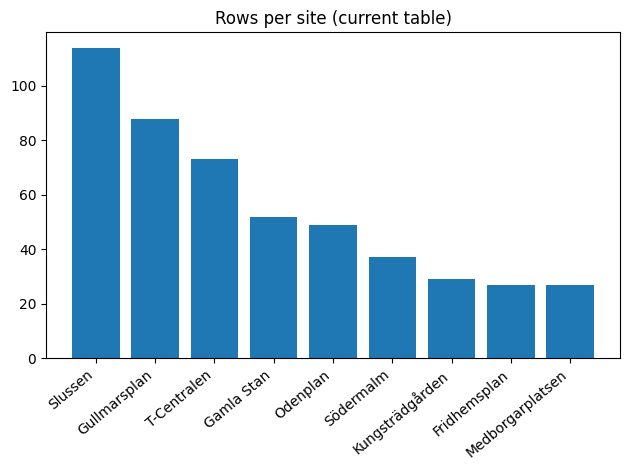

In [17]:
df_site = con.execute("""
select site_name, count(*) as rows
from raw_traffic.realtime_departures
group by 1
order by rows desc
""").fetchdf()

plt.figure()
plt.bar(df_site["site_name"], df_site["rows"])
plt.xticks(rotation=40, ha="right")
plt.title("Rows per site (current table)")
plt.tight_layout()
plt.show()


### Plot: deviations by site

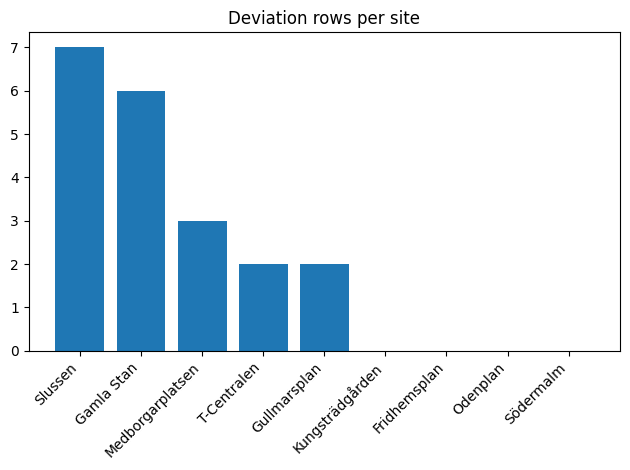

In [2]:
df_dev = con.execute("""
select site_name,
       sum(case when has_deviation then 1 else 0 end) as deviation_rows,
       count(*) as total_rows
from raw_traffic.realtime_departures
group by 1
order by deviation_rows desc
""").fetchdf()

plt.figure()
plt.bar(df_dev["site_name"], df_dev["deviation_rows"])
plt.xticks(rotation=45, ha="right")
plt.title("Deviation rows per site")
plt.tight_layout()
plt.show()


### one-run summary table

In [19]:
summary = con.execute("""
select
  site_name,
  count(*) as rows,
  sum(case when has_deviation then 1 else 0 end) as deviations,
  round(100.0 * sum(case when has_deviation then 1 else 0 end) / count(*), 2) as deviation_pct
from raw_traffic.realtime_departures
group by 1
order by rows desc
""").fetchdf()
summary


,site_name,rows,deviations,deviation_pct
0,Slussen,114,7.0,6.14
1,Gullmarsplan,88,2.0,2.27
2,T-Centralen,73,2.0,2.74
3,Gamla Stan,52,6.0,11.54
4,Odenplan,49,0.0,0.00
5,Södermalm,37,0.0,0.00
6,Kungsträdgården,29,0.0,0.00
7,Fridhemsplan,27,0.0,0.00
8,Medborgarplatsen,27,3.0,11.11


### Dot plots

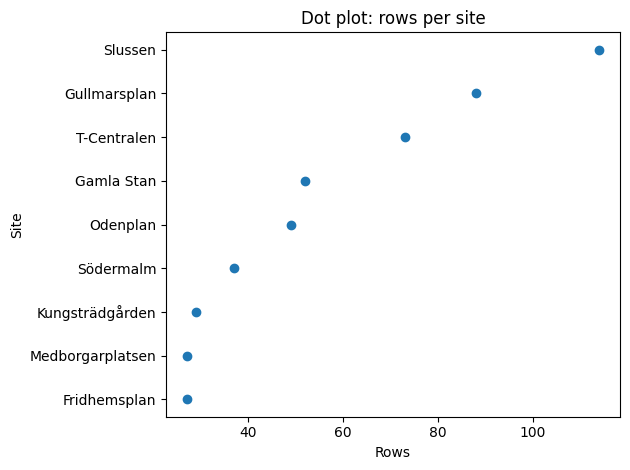

In [20]:
df_site = con.execute("""
select site_name, count(*) as rows
from raw_traffic.realtime_departures
group by 1
order by rows asc
""").fetchdf()

plt.figure()
plt.scatter(df_site["rows"], df_site["site_name"])
plt.xlabel("Rows")
plt.ylabel("Site")
plt.title("Dot plot: rows per site")
plt.tight_layout()
plt.show()


### rows by hour (needs timestamp parse)

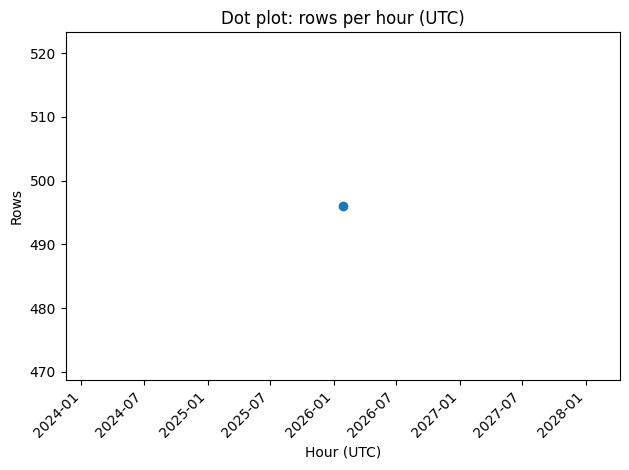

In [21]:
df_hour = con.execute("""
select
  date_trunc('hour', cast(ingestion_timestamp_utc as timestamptz)) as hour_utc,
  count(*) as rows
from raw_traffic.realtime_departures
group by 1
order by 1
""").fetchdf()

plt.figure()
plt.scatter(df_hour["hour_utc"], df_hour["rows"])
plt.xlabel("Hour (UTC)")
plt.ylabel("Rows")
plt.title("Dot plot: rows per hour (UTC)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Dot plot: top destinations

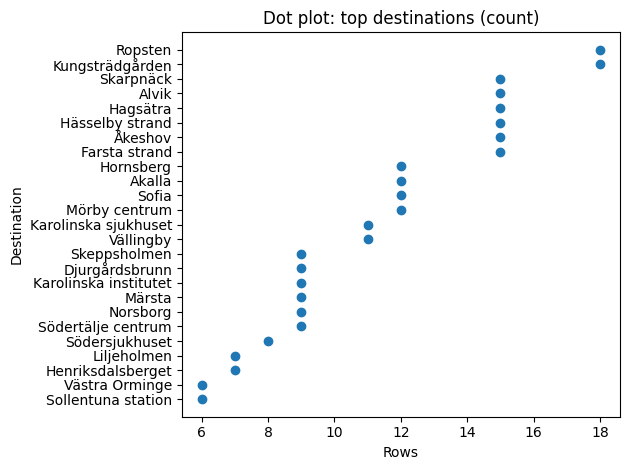

In [22]:
df_dest = con.execute("""
select destination, count(*) as rows
from raw_traffic.realtime_departures
where destination is not null and destination <> ''
group by 1
order by rows desc
limit 25
""").fetchdf().sort_values("rows", ascending=True)

plt.figure()
plt.scatter(df_dest["rows"], df_dest["destination"])
plt.xlabel("Rows")
plt.ylabel("Destination")
plt.title("Dot plot: top destinations (count)")
plt.tight_layout()
plt.show()


### Delay distribution

In [14]:
df_delay = con.execute("""
with base as (
  select
    site_name,
    destination,
    cast(expected_datetime as timestamptz)  as expected_ts,
    cast(scheduled_datetime as timestamptz) as scheduled_ts
  from raw_traffic.realtime_departures
  where expected_datetime is not null and scheduled_datetime is not null
),
calc as (
  select
    site_name,
    destination,
    datediff('minute', scheduled_ts, expected_ts) as delay_minutes
  from base
)
select *
from calc
where delay_minutes is not null
""").fetchdf()

df_delay.head(10)



,site_name,destination,delay_minutes
0,T-Centralen,Hornsberg,2
1,T-Centralen,Djurgårdsbrunn,1
2,T-Centralen,Hjulsta,0
3,T-Centralen,Waldemarsudde,0
4,T-Centralen,Åkeshov,0
5,T-Centralen,Hagsätra,0
6,T-Centralen,Mörby centrum,0
7,T-Centralen,Kungsträdgården,0
8,T-Centralen,Tumba,0
9,T-Centralen,Norsborg,0


### Histogram

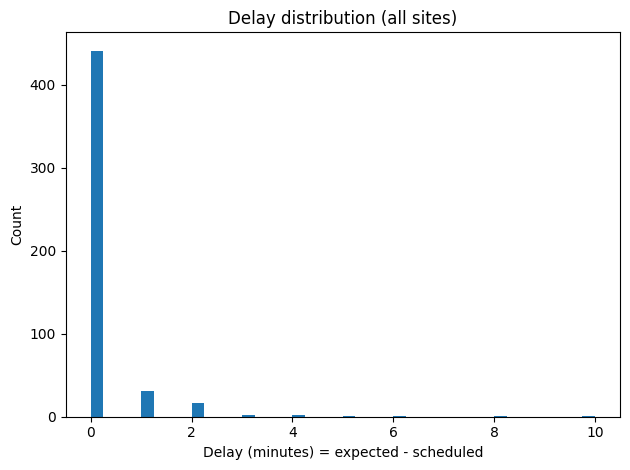

In [15]:
plt.figure()
plt.hist(df_delay["delay_minutes"], bins=40)
plt.xlabel("Delay (minutes) = expected - scheduled")
plt.ylabel("Count")
plt.title("Delay distribution (all sites)")
plt.tight_layout()
plt.show()


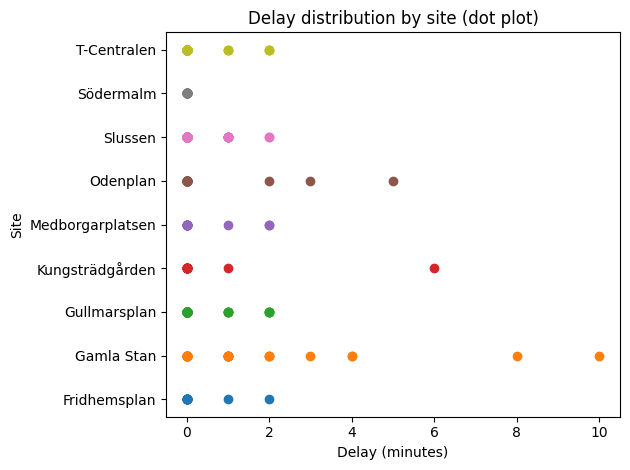

In [16]:
df_site_delay = df_delay.groupby("site_name")["delay_minutes"].apply(list).reset_index()

plt.figure()
for _, row in df_site_delay.iterrows():
    site = row["site_name"]
    delays = row["delay_minutes"]
    plt.scatter(delays, [site] * len(delays))

plt.xlabel("Delay (minutes)")
plt.ylabel("Site")
plt.title("Delay distribution by site (dot plot)")
plt.tight_layout()
plt.show()


###  Compute delay with filter (-10 to +60)

In [17]:
df_delay = con.execute("""
with base as (
  select
    site_name,
    destination,
    cast(expected_datetime as timestamptz)  as expected_ts,
    cast(scheduled_datetime as timestamptz) as scheduled_ts
  from raw_traffic.realtime_departures
  where expected_datetime is not null and scheduled_datetime is not null
),
calc as (
  select
    site_name,
    destination,
    datediff('minute', scheduled_ts, expected_ts) as delay_minutes
  from base
)
select *
from calc
where delay_minutes between -10 and 60
""").fetchdf()

df_delay.describe()


,delay_minutes
count,496.000000
mean,0.213710
std,0.837682
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,10.000000


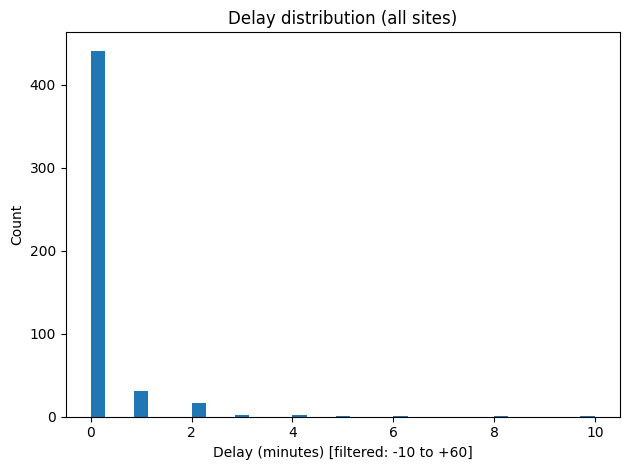

In [18]:
plt.figure()
plt.hist(df_delay["delay_minutes"], bins=35)
plt.xlabel("Delay (minutes) [filtered: -10 to +60]")
plt.ylabel("Count")
plt.title("Delay distribution (all sites)")
plt.tight_layout()
plt.show()


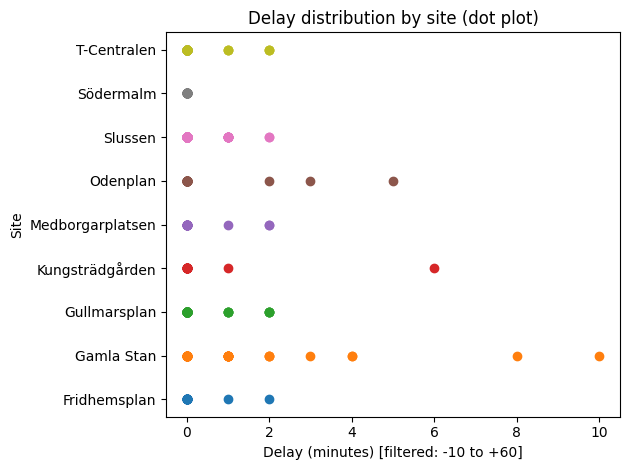

In [19]:
df_site_delay = df_delay.groupby("site_name")["delay_minutes"].apply(list).reset_index()

plt.figure()
for _, row in df_site_delay.iterrows():
    site = row["site_name"]
    delays = row["delay_minutes"]
    plt.scatter(delays, [site] * len(delays))

plt.xlabel("Delay (minutes) [filtered: -10 to +60]")
plt.ylabel("Site")
plt.title("Delay distribution by site (dot plot)")
plt.tight_layout()
plt.show()


### Stop-level hotspots

In [20]:
df_hot_sites = con.execute("""
with base as (
  select
    site_id,
    site_name,
    cast(expected_datetime as timestamptz)  as expected_ts,
    cast(scheduled_datetime as timestamptz) as scheduled_ts
  from raw_traffic.realtime_departures
  where expected_datetime is not null and scheduled_datetime is not null
),
calc as (
  select
    site_id,
    site_name,
    datediff('minute', scheduled_ts, expected_ts) as delay_minutes
  from base
),
flt as (
  select *
  from calc
  where delay_minutes between -10 and 60
)
select
  site_id,
  site_name,
  count(*) as obs,
  round(avg(delay_minutes), 2) as avg_delay_min,
  round(median(delay_minutes), 2) as med_delay_min,
  round(quantile_cont(delay_minutes, 0.95), 2) as p95_delay_min,
  sum(case when delay_minutes >= 10 then 1 else 0 end) as big_delay_cnt,
  round(100.0 * sum(case when delay_minutes >= 10 then 1 else 0 end) / count(*), 2) as big_delay_pct
from flt
group by 1,2
having count(*) >= 30
order by avg_delay_min desc, big_delay_pct desc
""").fetchdf()

df_hot_sites


,site_id,site_name,obs,avg_delay_min,med_delay_min,p95_delay_min,big_delay_cnt,big_delay_pct
0,9190,Gamla Stan,52,0.87,0.0,4.0,1.0,1.92
1,9204,Odenplan,49,0.20,0.0,1.2,0.0,0.00
2,1080,Gullmarsplan,88,0.14,0.0,1.0,0.0,0.00
3,9192,Slussen,114,0.13,0.0,1.0,0.0,0.00
4,9001,T-Centralen,73,0.12,0.0,1.0,0.0,0.00
5,9506,Södermalm,37,0.00,0.0,0.0,0.0,0.00


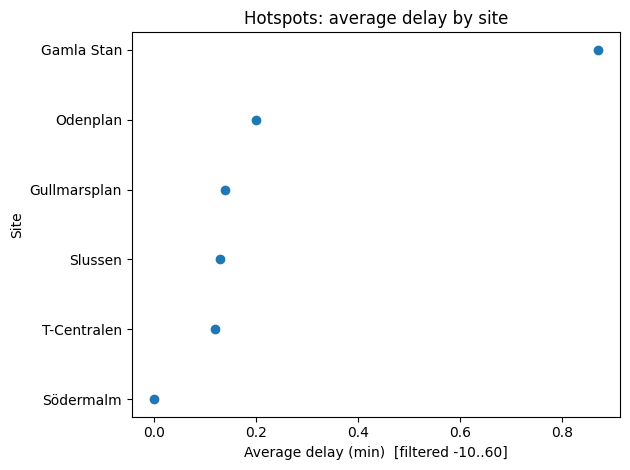

In [21]:
df_plot = df_hot_sites.sort_values("avg_delay_min", ascending=True)

plt.figure()
plt.scatter(df_plot["avg_delay_min"], df_plot["site_name"])
plt.xlabel("Average delay (min)  [filtered -10..60]")
plt.ylabel("Site")
plt.title("Hotspots: average delay by site")
plt.tight_layout()
plt.show()


### Dot plot: % big delays (>=10 min) hotspots

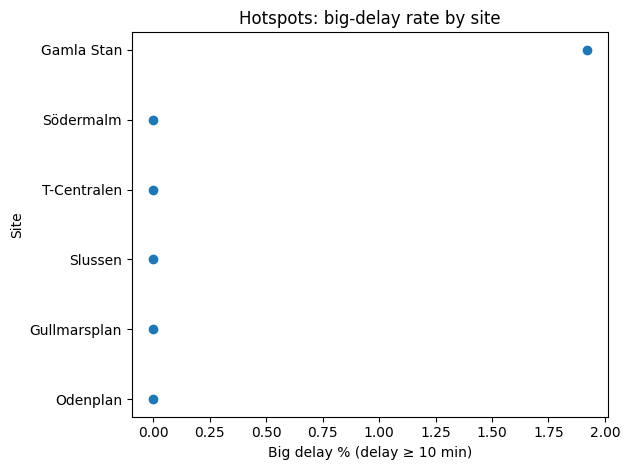

In [22]:
df_plot = df_hot_sites.sort_values("big_delay_pct", ascending=True)

plt.figure()
plt.scatter(df_plot["big_delay_pct"], df_plot["site_name"])
plt.xlabel("Big delay % (delay ≥ 10 min)")
plt.ylabel("Site")
plt.title("Hotspots: big-delay rate by site")
plt.tight_layout()
plt.show()


In [23]:
df_hot_stops = con.execute("""
with base as (
  select
    site_id,
    site_name,
    stop_point,
    cast(expected_datetime as timestamptz)  as expected_ts,
    cast(scheduled_datetime as timestamptz) as scheduled_ts
  from raw_traffic.realtime_departures
  where expected_datetime is not null
    and scheduled_datetime is not null
    and stop_point is not null
    and stop_point <> ''
),
calc as (
  select
    site_id,
    site_name,
    stop_point,
    datediff('minute', scheduled_ts, expected_ts) as delay_minutes
  from base
),
flt as (
  select *
  from calc
  where delay_minutes between -10 and 60
)
select
  site_name,
  stop_point,
  count(*) as obs,
  round(avg(delay_minutes), 2) as avg_delay_min,
  round(quantile_cont(delay_minutes, 0.95), 2) as p95_delay_min
from flt
group by 1,2
having count(*) >= 20
order by avg_delay_min desc
limit 25
""").fetchdf()

df_hot_stops


,site_name,stop_point,obs,avg_delay_min,p95_delay_min


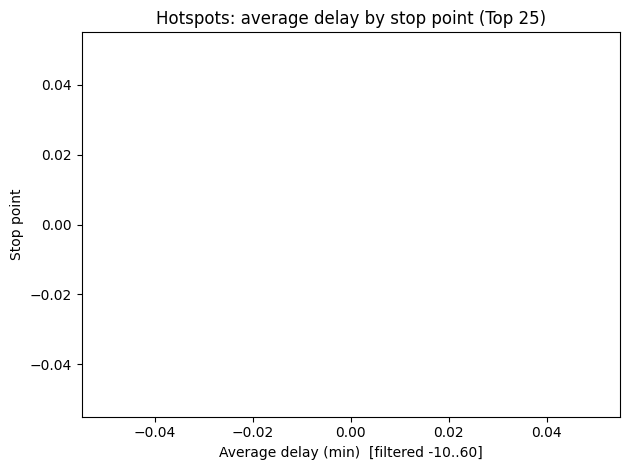

In [24]:
df_plot = df_hot_stops.sort_values("avg_delay_min", ascending=True)

plt.figure()
plt.scatter(df_plot["avg_delay_min"], df_plot["stop_point"])
plt.xlabel("Average delay (min)  [filtered -10..60]")
plt.ylabel("Stop point")
plt.title("Hotspots: average delay by stop point (Top 25)")
plt.tight_layout()
plt.show()


In [25]:
df_ml = con.execute("""
with base as (
  select
    site_id,
    site_name,
    line,
    destination,
    has_deviation,
    cast(expected_datetime as timestamptz)  as expected_ts,
    cast(scheduled_datetime as timestamptz) as scheduled_ts,
    extract(hour from cast(scheduled_datetime as timestamptz)) as hour_of_day,
    extract(dow  from cast(scheduled_datetime as timestamptz)) as day_of_week
  from raw_traffic.realtime_departures
  where expected_datetime is not null
    and scheduled_datetime is not null
),
calc as (
  select *,
    datediff('minute', scheduled_ts, expected_ts) as delay_minutes
  from base
)
select *
from calc
where delay_minutes between -10 and 60
""").fetchdf()

df_ml.head()

,site_id,site_name,line,destination,has_deviation,expected_ts,scheduled_ts,hour_of_day,day_of_week,delay_minutes
0,9001,T-Centralen,None,Hornsberg,False,2026-01-27 11:21:15+01:00,2026-01-27 11:19:29+01:00,11,2,2
1,9001,T-Centralen,None,Djurgårdsbrunn,False,2026-01-27 11:22:06+01:00,2026-01-27 11:21:09+01:00,11,2,1
2,9001,T-Centralen,None,Hjulsta,False,2026-01-27 11:22:42+01:00,2026-01-27 11:22:42+01:00,11,2,0
3,9001,T-Centralen,None,Waldemarsudde,False,2026-01-27 11:23:00+01:00,2026-01-27 11:23:00+01:00,11,2,0
4,9001,T-Centralen,None,Åkeshov,False,2026-01-27 11:23:42+01:00,2026-01-27 11:23:42+01:00,11,2,0


In [26]:
def delay_class(x):
    if x <= 0:
        return "on_time"
    elif x <= 5:
        return "minor_delay"
    else:
        return "major_delay"

df_ml["delay_class"] = df_ml["delay_minutes"].apply(delay_class)
df_ml["delay_class"].value_counts(normalize=True)


delay_class
on_time        0.889113
minor_delay    0.104839
major_delay    0.006048
Name: proportion, dtype: float64

In [28]:
features = [
    "site_name",
    "hour_of_day",
    "day_of_week",
    "has_deviation"
]

X = df_ml[features]
y = df_ml["delay_class"]


### Encode + train baseline model

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

categorical = ["site_name"]
numeric = ["hour_of_day", "day_of_week", "has_deviation"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric),
    ]
)

model = Pipeline(
    steps=[
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=1000))
    ]
)

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### Feature importance

In [30]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

 major_delay       0.00      0.00      0.00         1
 minor_delay       0.00      0.00      0.00        13
     on_time       0.89      1.00      0.94       110

    accuracy                           0.89       124
   macro avg       0.30      0.33      0.31       124
weighted avg       0.79      0.89      0.83       124



c:\Users\mdnrl\Documents\github\Ex_Jobb_Data_pipeline_for_Stockholm_Traffic_-_Transit\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mdnrl\Documents\github\Ex_Jobb_Data_pipeline_for_Stockholm_Traffic_-_Transit\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mdnrl\Documents\github\Ex_Jobb_Data_pipeline_for_Stockholm_Traffic_-_Transit\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0

## EDA Summary

- Comprehensive real-time coverage was successfully established across major Stockholm transit hubs (e.g. T-Centralen, Slussen, Odenplan), capturing high-frequency departure data from multiple public transport services including metro, bus, commuter rail, and light rail.
- Delay distributions are right-skewed, with the majority of departures being on-time or experiencing minor delays, while a smaller but operationally significant share exhibits larger delays.
- Clear temporal patterns were identified: delay frequency and magnitude increase during peak travel hours and vary by time of day and day of week.
- Stop-level heterogeneity is evident: certain stations consistently show higher average delays and higher proportions of major delays, indicating localized operational bottlenecks (“delay hotspots”).
- Deviation flags are strongly associated with increased delays, validating their usefulness as an explanatory feature for predictive modeling.